In [ ]:
from datasets import load_dataset
import numpy as np
from tqdm import tqdm

data = load_dataset("stanford-vision-lab/gpic", split="validation", streaming=True)
data = data.filter(
    lambda ex: ex["jpg"] is not None
               and ex["json"]["caption"] is not None
)

print(next(iter(data)))

Resolving data files:   0%|          | 0/8001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/128 [00:00<?, ?it/s]

{'json': {'retrieved_at': '2026-01-22T17:27:28+00:00', 'license': 'CC BY 2.0', 'license_url': 'https://creativecommons.org/licenses/by/2.0/', 'attribution': 'by 13207451@N00 — source: https://www.flickr.com/photos/13207451@N00/16616449892 — license: CC BY 2.0 (https://creativecommons.org/licenses/by/2.0/)', 'key': '005a13525e45210df2a71777a9060032b3221dbee0e39d5344213385b23c8814', 'img_width': 640, 'img_height': 480, 'split': ['val'], 'caption_type': 'short', 'caption': 'A person with dreadlocks and a red bow sits at a table with art posters and stickers.'}, 'jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x22E072FF590>, '__key__': '005a13525e45210df2a71777a9060032b3221dbee0e39d5344213385b23c8814', '__url__': 'hf://datasets/stanford-vision-lab/gpic@0634c6f3d596ac40abf8364764f1047f5486ef76/val/gpic_val_00000.tar'}


In [24]:
from IPython.display import display
from ipywidgets import interact, IntSlider

# O(n) but who cares    
def show_image(image_idx):
    for i, sample in enumerate(data):
        if (i == image_idx):
            print(sample['jpg'].size) # W, H
            return display(sample['jpg'])

interact(show_image, image_idx=IntSlider(min=0, max=1000))
# show_image(image_idx=0)

interactive(children=(IntSlider(value=0, description='image_idx', max=1000), Output()), _dom_classes=('widget-…

<function __main__.show_image(image_idx)>

### Data to tensor & tensor to image
Turning image into $C \times H \times W$ tensor and reversing tensor back to image.

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x22E039484A0>


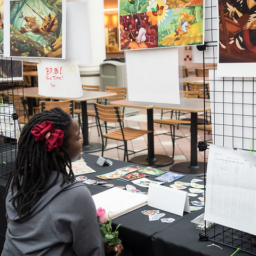

In [2]:
import torch
import torch.nn as nn
import einops
from torchvision.transforms import ToTensor, ToPILImage, transforms

to_tensor = ToTensor()
to_image = ToPILImage()

img = next(iter(data))['jpg']
tensor = to_tensor(img) # c x h x w
to_image(tensor) # convert back to image!

d = 256
transform = transforms.Compose(
    [
        transforms.Resize(d),
        transforms.CenterCrop(d),
        transforms.Lambda(lambda image: image.convert("RGB")), # just making sure
    ]
)

print(img)
transform(img)


Create testing dataset via streaming.

In [41]:
d = 256
def create_batch(batch_size: int) -> torch.Tensor:
    tensor = torch.empty((batch_size, 3, d, d), dtype=torch.float32)
    
    i = 0
    for sample in data:
        img = sample['jpg']
        if img is None:
            continue
        
        if (i == batch_size):
            break
        tensor[i] = to_tensor(transform(img))
        i += 1
    return tensor
        

In [43]:
torch.save(create_batch(64), "RGBImageTensors.pt")

In [36]:
def patchify2DCONV(x, p, d):
    C, H, W = x.shape
    conv = nn.Conv2d(in_channels=C, out_channels=d, kernel_size=p, stride=p)
    # LINEAR 2x2x4 -> 2x8 (p=2) -> (2x8) @ (8 x d) -> 2xd 
    # CONV   CxHxW -> DxH/pxW/p -> DxN -> 2xNxD
    return einops.rearrange(conv(x), "d h w -> (h w) d")


In [43]:
patchify2DCONV(to_tensor(transform(img)), p=4, d = 512).shape

torch.Size([4096, 512])

Download `.tar` files directly

In [33]:
from huggingface_hub import hf_hub_download, list_repo_files

files = list_repo_files(
    "stanford-vision-lab/gpic",
    repo_type="dataset",
)

total_shards = 3
folder_dir = "./validation"
i = 0
for f in files:
    if f.startswith("val/"):
        filename = f.split("/")[-1]
        print(f, i)
        hf_hub_download(repo_id="stanford-vision-lab/gpic",
                        subfolder="val",
                        filename=filename,
                        repo_type="dataset",
                        local_dir=folder_dir)
        i += 1
        if (i == total_shards):
            break

val/gpic_val_00000.tar 0
val/gpic_val_00001.tar 1
val/gpic_val_00002.tar 2


In [ ]:
import os
if not os.path.exists("data/"):
    os.makedirs("data/")
    os.makedirs("data/images")
    os.makedirs("data/captions")
    
# data.save_to_disk("./testing")